In [9]:
!pip uninstall -y transformers peft diffusers torchao
!pip install -q transformers==4.46.3
!pip install -q peft==0.17.1
!pip install -q diffusers==0.35.1
!pip install -q accelerate safetensors bitsandbytes

Found existing installation: transformers 4.46.3
Uninstalling transformers-4.46.3:
  Successfully uninstalled transformers-4.46.3
Found existing installation: peft 0.17.1
Uninstalling peft-0.17.1:
  Successfully uninstalled peft-0.17.1
Found existing installation: diffusers 0.35.1
Uninstalling diffusers-0.35.1:
  Successfully uninstalled diffusers-0.35.1


In [10]:
from huggingface_hub import notebook_login
notebook_login()

In [12]:
import os

dataset_path = "dataset/processed"
print(os.listdir(dataset_path))

['processed_08.jpeg', 'processed_04.jpeg', 'processed_05.jpeg', 'processed_01.jpeg', 'processed_09.jpeg', 'processed_00.jpeg', 'processed_02.jpeg', 'processed_07.jpeg', 'processed_03.jpeg', 'processed_06.jpeg']


In [11]:
!git clone https://github.com/mtaarik/textual-inversion-generative-ai.git
%cd textual-inversion-generative-ai

Cloning into 'textual-inversion-generative-ai'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 60 (delta 4), reused 53 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 8.89 MiB | 16.52 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/textual-inversion-generative-ai/textual-inversion-generative-ai


In [13]:
!wget https://raw.githubusercontent.com/huggingface/diffusers/v0.35.1/examples/dreambooth/train_dreambooth_lora.py

--2026-05-23 23:06:55--  https://raw.githubusercontent.com/huggingface/diffusers/v0.35.1/examples/dreambooth/train_dreambooth_lora.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 59186 (58K) [text/plain]
Saving to: ‘train_dreambooth_lora.py’

train_dreambooth_lo 100%[===================>]  57.80K  --.-KB/s    in 0.007s  

2026-05-23 23:06:55 (7.64 MB/s) - ‘train_dreambooth_lora.py’ saved [59186/59186]



In [14]:
!accelerate launch train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="dataset/processed" \
  --output_dir="dreambooth_lora_output" \
  --instance_prompt="a photo of sks toycar" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=800 \
  --checkpointing_steps=200 \
  --mixed_precision="fp16" \
  --gradient_checkpointing

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-05-23 23:07:21.201748: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
05/23/2026 23:07:32 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

You are using a model of type clip_text_model to instantiate a model of type . This is not supported for 

In [15]:
from diffusers import StableDiffusionPipeline
import torch
import os

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

pipe.load_lora_weights("dreambooth_lora_output")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

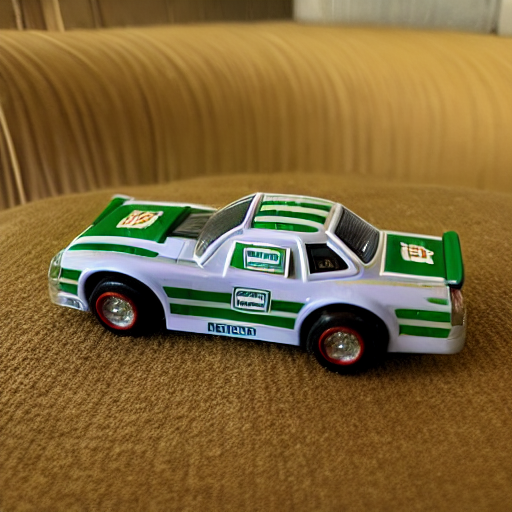

  0%|          | 0/50 [00:00<?, ?it/s]

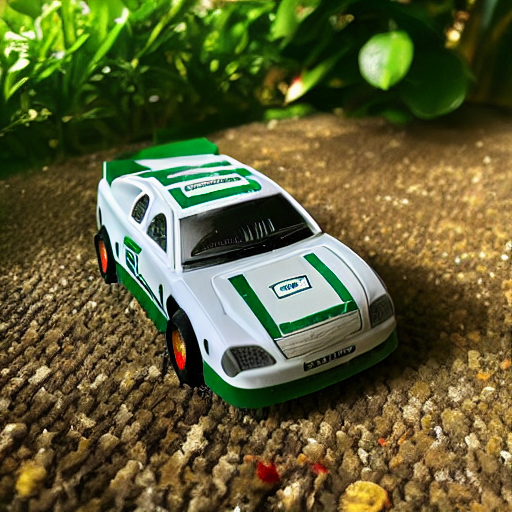

  0%|          | 0/50 [00:00<?, ?it/s]

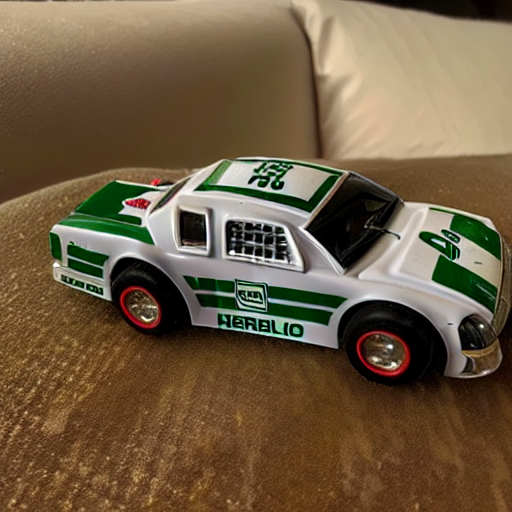

  0%|          | 0/50 [00:00<?, ?it/s]

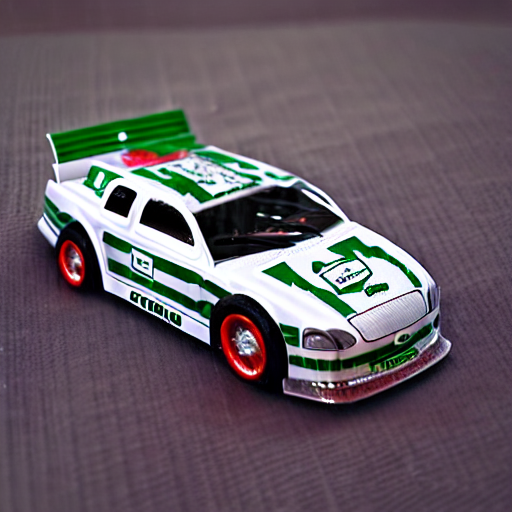

In [16]:
os.makedirs("results/dreambooth", exist_ok=True)

prompts = [
    "a photo of sks toycar on a table",
    "a photo of sks toycar in a garden",
    "a close-up photo of sks toycar",
    "a cartoon style image of sks toycar"
]

for i, prompt in enumerate(prompts, start=1):
    image = pipe(prompt).images[0]
    image.save(f"results/dreambooth/dreambooth_result{i}.png")
    display(image)

In [22]:
!du -h dreambooth_lora_output/pytorch_lora_weights.safetensors

3.1M	dreambooth_lora_output/pytorch_lora_weights.safetensors
